In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [24]:
def neuron(x, w):
    z = np.dot(x, w)
    a = sigmoid(z)
    return a

In [28]:
x = np.array([[1, 150, 10],
              [1, 170, 15]])
x.shape

(2, 3)

In [29]:
w = np.array([[1],
              [2],
              [0.5]])
w.shape

(3, 1)

In [30]:
neuron(x, w)

array([[1.],
       [1.]])

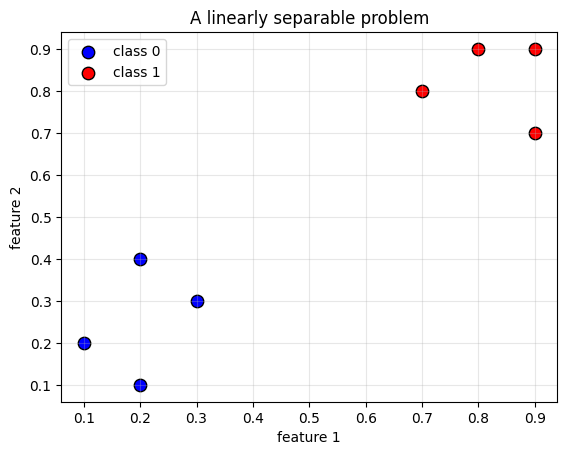

In [183]:
# 8 examples, 2 features each
X = np.array([[1, 0.1,0.2],[1, 0.2,0.1],[1, 0.3,0.3],[1, 0.2,0.4],    # class 0 (low values)
              [1, 0.8,0.9],[1, 0.9,0.7],[1, 0.7,0.8],[1, 0.9,0.9]])    # class 1 (high values)
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

plt.scatter(X[y==0,1], X[y==0,2], c="blue", s=80, edgecolor="k", label="class 0")
plt.scatter(X[y==1,1], X[y==1,2], c="red", s=80, edgecolor="k", label="class 1")
plt.xlabel("feature 1"); 
plt.ylabel("feature 2"); 
plt.legend()
plt.title("A linearly separable problem"); 
plt.grid(alpha=0.3)
plt.show()

In [184]:
X.shape

(8, 3)

In [185]:
y.shape

(8,)

In [188]:
def neuron(x, w):
    z = np.dot(x, w)
    a = sigmoid(z)
    return a

In [189]:
def cost(X, y, w):
    y_hat = neuron(X, w)
    c = np.mean(-(y*np.log(y_hat+1.0e-10) + (1-y)*np.log(1-y_hat+1e-10)))
    return c


In [203]:
def gradient(X, y, w):
    y_hat = neuron(X, w)
    error = y_hat - y
    gwb = np.mean(error*X.T, axis=1) 
    return gwb

In [194]:
X.shape[1]

3

In [195]:
w = np.zeros(X.shape[1])

In [197]:
w

array([0., 0., 0.])

In [198]:
neuron(X, w)

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

In [199]:
cost(X, y, w)

0.6931471803599453

In [204]:
gradient(X, y, w)

array([ 0.     , -0.15625, -0.14375])

In [206]:
learning_rate = 0.01
costs = []
accuracies = []
epochs = 1000

for epoch in range(1, epochs+1):
    gwb = gradient(X, y, w)
    w = w.flatten() - learning_rate*gwb

    c = cost(X, y, w)
    costs.append(c)

    preb = neuron(X, w)
    pred = np.where(preb>=0.5, 1, 0)

    acc = ((y == pred).sum()/8)*100
    accuracies.append(acc)

    print(f"Epoch : {epoch} --  Cost : {c}  --  Accuracy : {acc}")





Epoch : 1 --  Cost : 0.6922481071263342  --  Accuracy : 50.0
Epoch : 2 --  Cost : 0.6918010444152867  --  Accuracy : 50.0
Epoch : 3 --  Cost : 0.6913556147001573  --  Accuracy : 50.0
Epoch : 4 --  Cost : 0.6909118058921053  --  Accuracy : 50.0
Epoch : 5 --  Cost : 0.6904696059952214  --  Accuracy : 50.0
Epoch : 6 --  Cost : 0.6900290031059089  --  Accuracy : 50.0
Epoch : 7 --  Cost : 0.6895899854122646  --  Accuracy : 50.0
Epoch : 8 --  Cost : 0.6891525411934636  --  Accuracy : 50.0
Epoch : 9 --  Cost : 0.6887166588191456  --  Accuracy : 50.0
Epoch : 10 --  Cost : 0.688282326748803  --  Accuracy : 50.0
Epoch : 11 --  Cost : 0.6878495335311717  --  Accuracy : 50.0
Epoch : 12 --  Cost : 0.6874182678036247  --  Accuracy : 50.0
Epoch : 13 --  Cost : 0.6869885182915669  --  Accuracy : 50.0
Epoch : 14 --  Cost : 0.6865602738078329  --  Accuracy : 50.0
Epoch : 15 --  Cost : 0.6861335232520873  --  Accuracy : 50.0
Epoch : 16 --  Cost : 0.6857082556102272  --  Accuracy : 50.0
Epoch : 17 --  Cos

In [207]:
len(costs)

1000

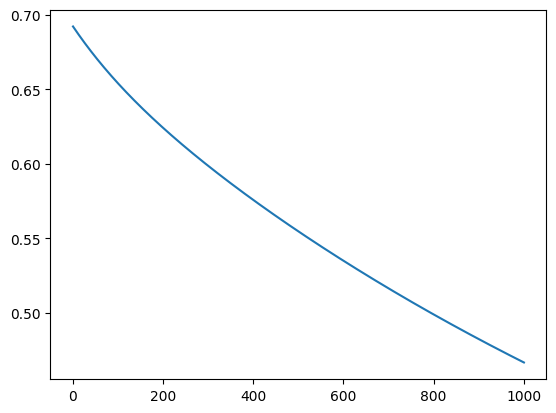

In [211]:
plt.plot(list(range(1, 1001)), costs, label="Cost")

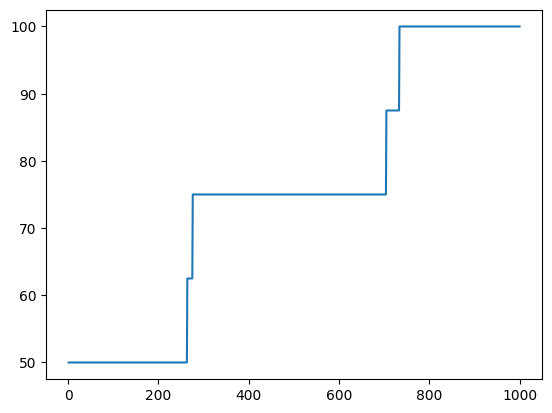

In [212]:
plt.plot(list(range(1, 1001)), accuracies, label="acc")


In [214]:
x_line = np.array([X[:, 1].min(), X[:, 1].max()])
y_line = -(w[0] + w[1]*x_line)/w[2]

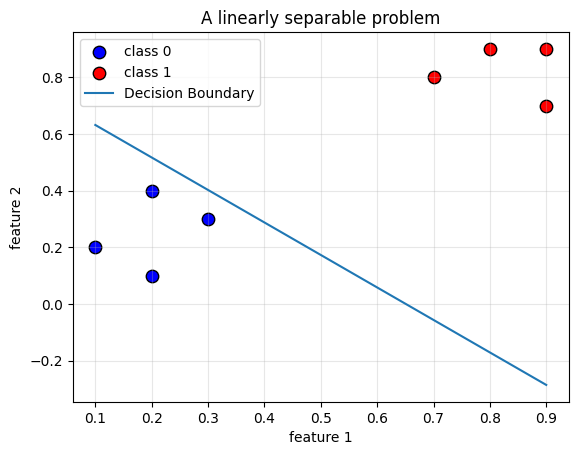

In [215]:
plt.scatter(X[y==0,1], X[y==0,2], c="blue", s=80, edgecolor="k", label="class 0")
plt.scatter(X[y==1,1], X[y==1,2], c="red", s=80, edgecolor="k", label="class 1")
plt.plot(x_line, y_line, label='Decision Boundary')
plt.xlabel("feature 1"); 
plt.ylabel("feature 2"); 
plt.legend()
plt.title("A linearly separable problem"); 
plt.grid(alpha=0.3)
plt.show()